Libraries imported and visualization styling applied successfully.
Dataset Successfully Loaded from SQLite Warehouse.
Total Rows: 284,807
Total Columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 32 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   V1             284807 non-null  float64
 1   V2             284807 non-null  float64
 2   V3             284807 non-null  float64
 3   V4             284807 non-null  float64
 4   V5             284807 non-null  float64
 5   V6             284807 non-null  float64
 6   V7             284807 non-null  float64
 7   V8             284807 non-null  float64
 8   V9             284807 non-null  float64
 9   V10            284807 non-null  float64
 10  V11            284807 non-null  float64
 11  V12            284807 non-null  float64
 12  V13            284807 non-null  float64
 13  V14            284807 non-null  float64
 14  V15            2848

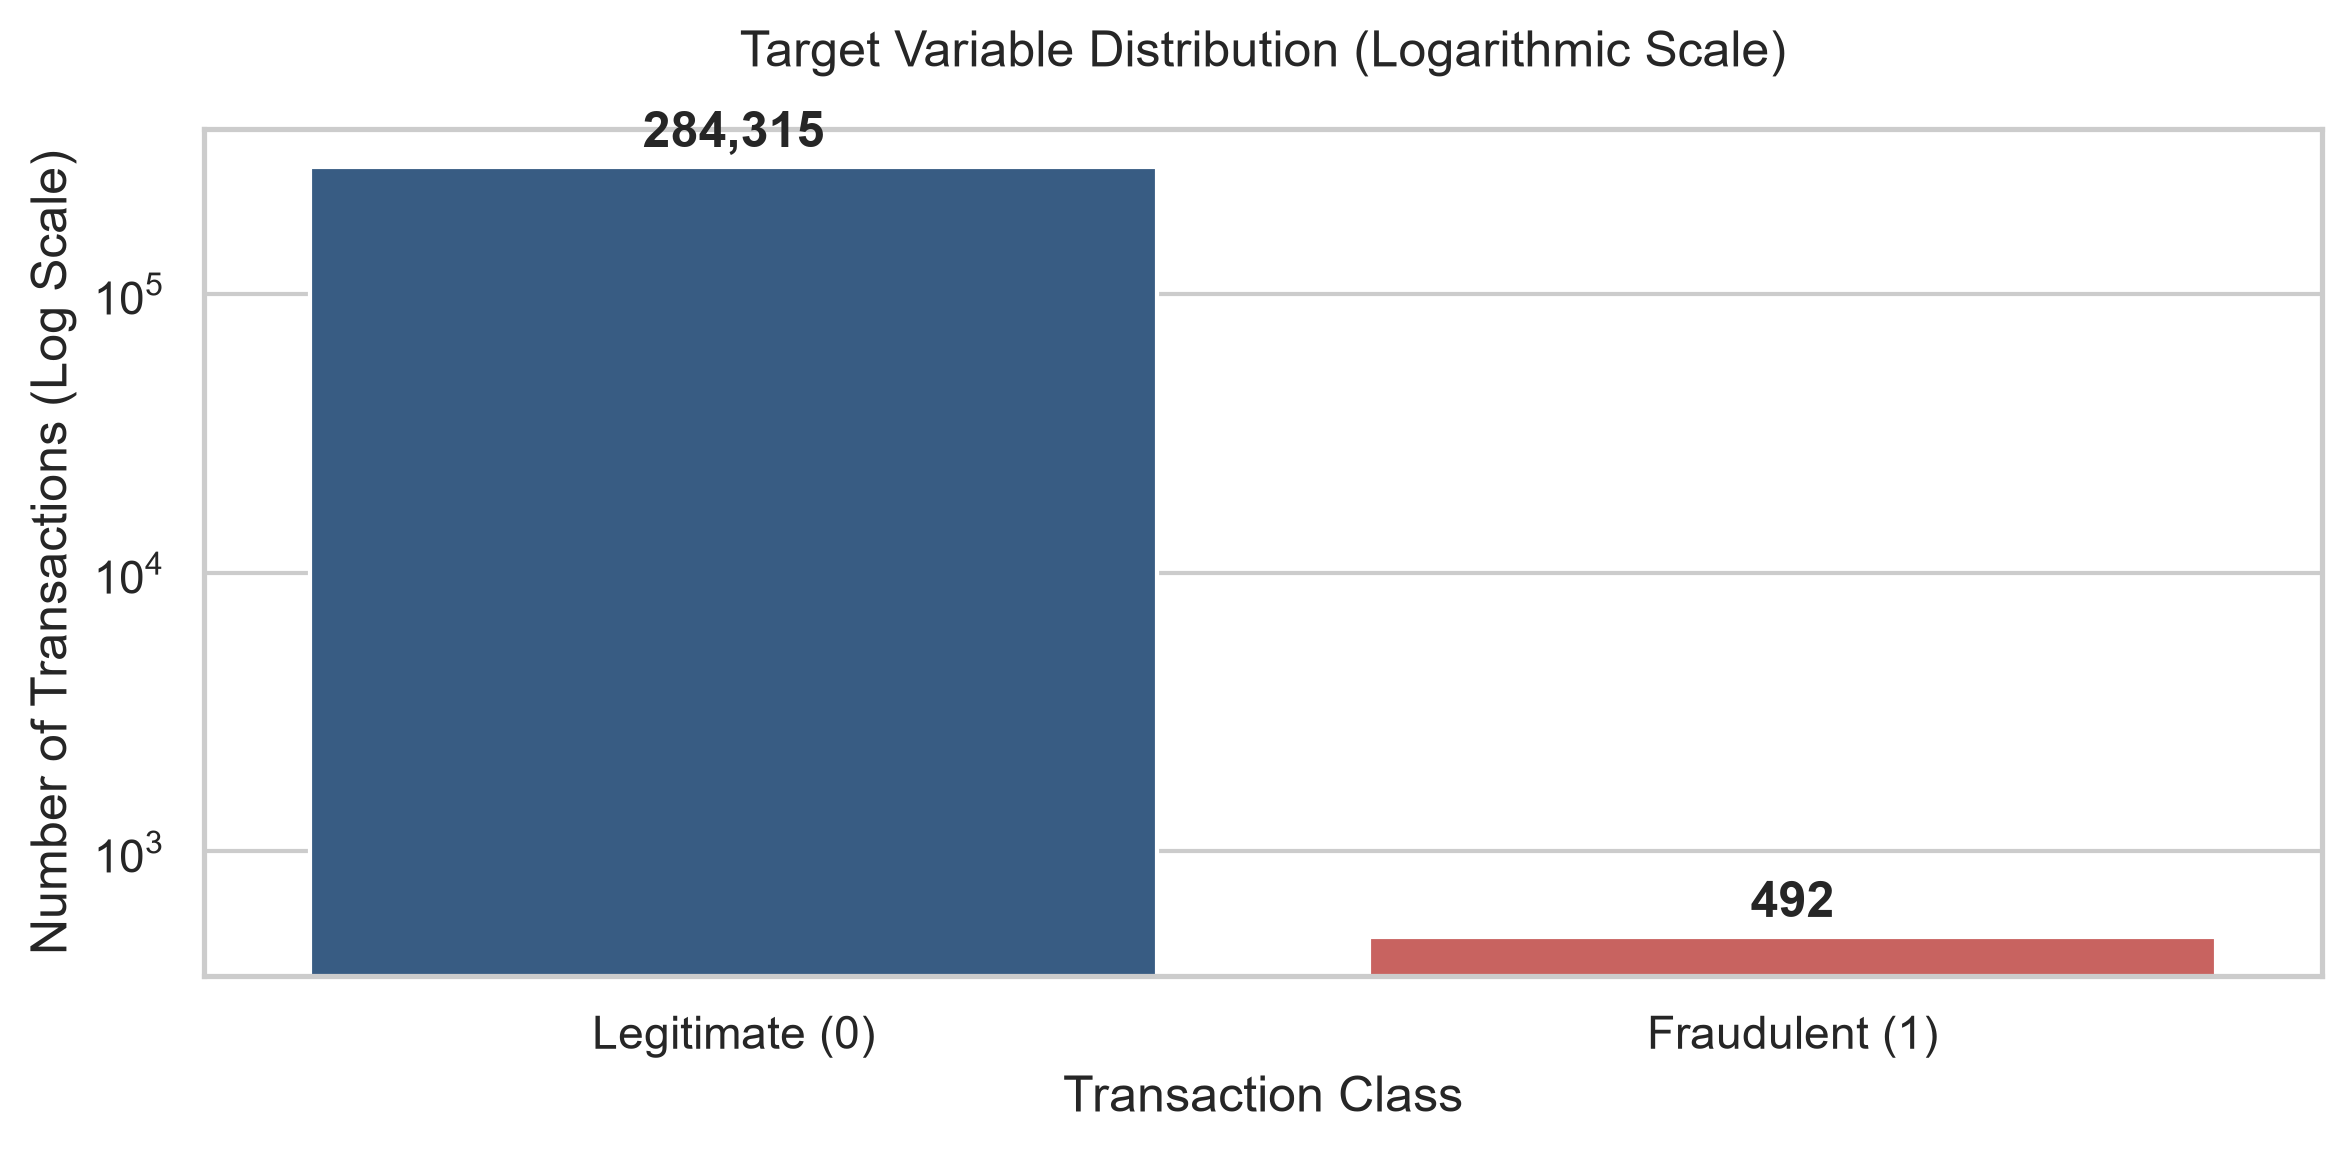

--- Descriptive Statistics: Scaled Transaction Amount ---
       Legitimate (Class 0)  Fraudulent (Class 1)
count           284315.0000              492.0000
mean                 0.9263                1.4003
std                  3.4948                3.5867
min                 -0.3074               -0.3074
25%                 -0.2285               -0.2934
50%                  0.0000               -0.1782
75%                  0.7692                1.1722
max                358.6832               29.3980
IQR                  0.9977                1.4657


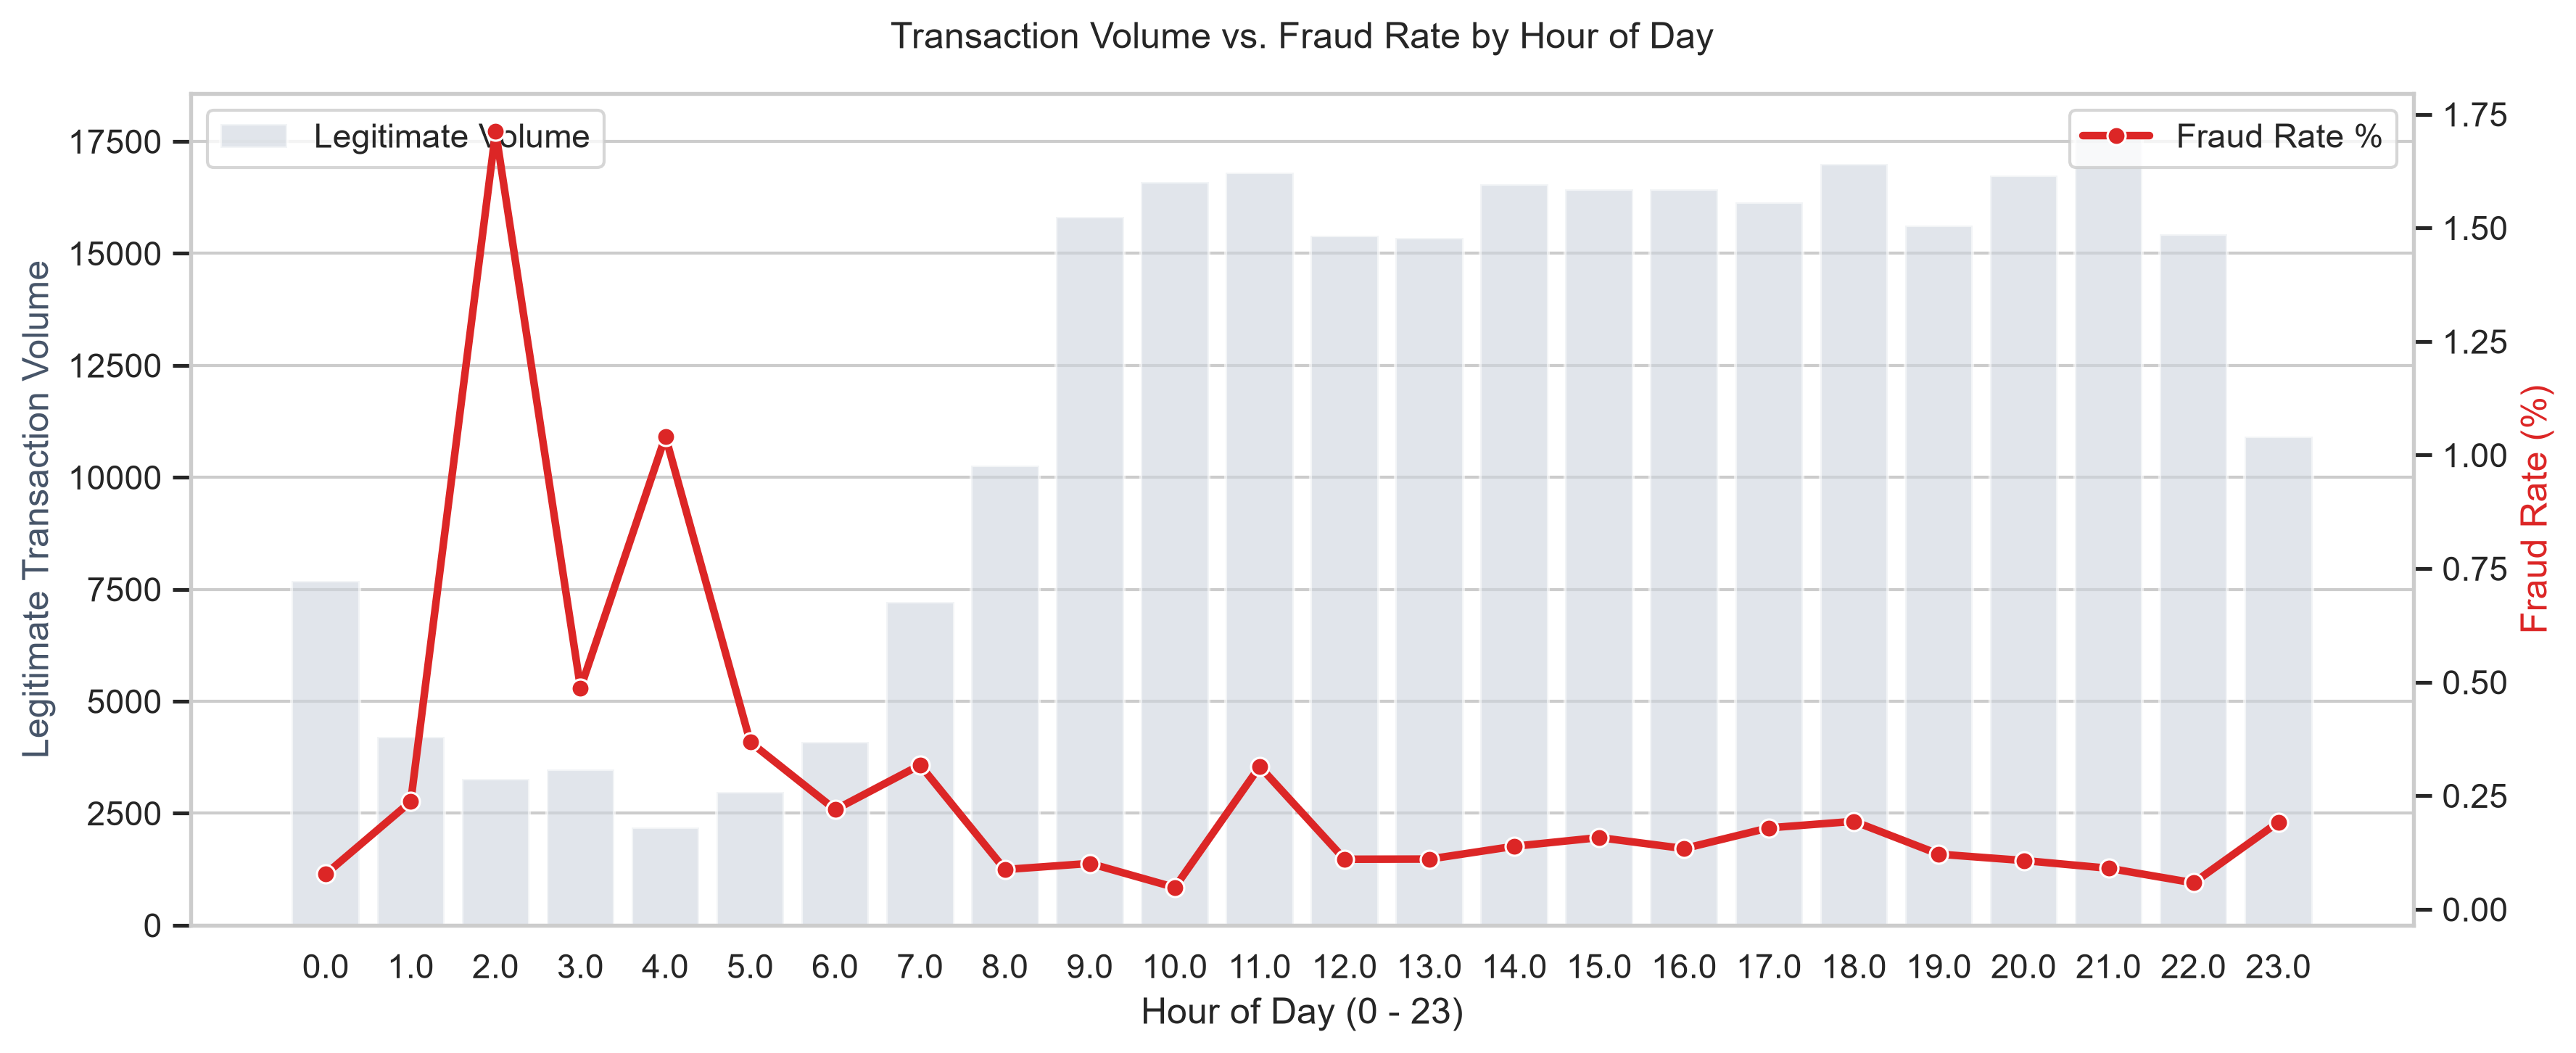

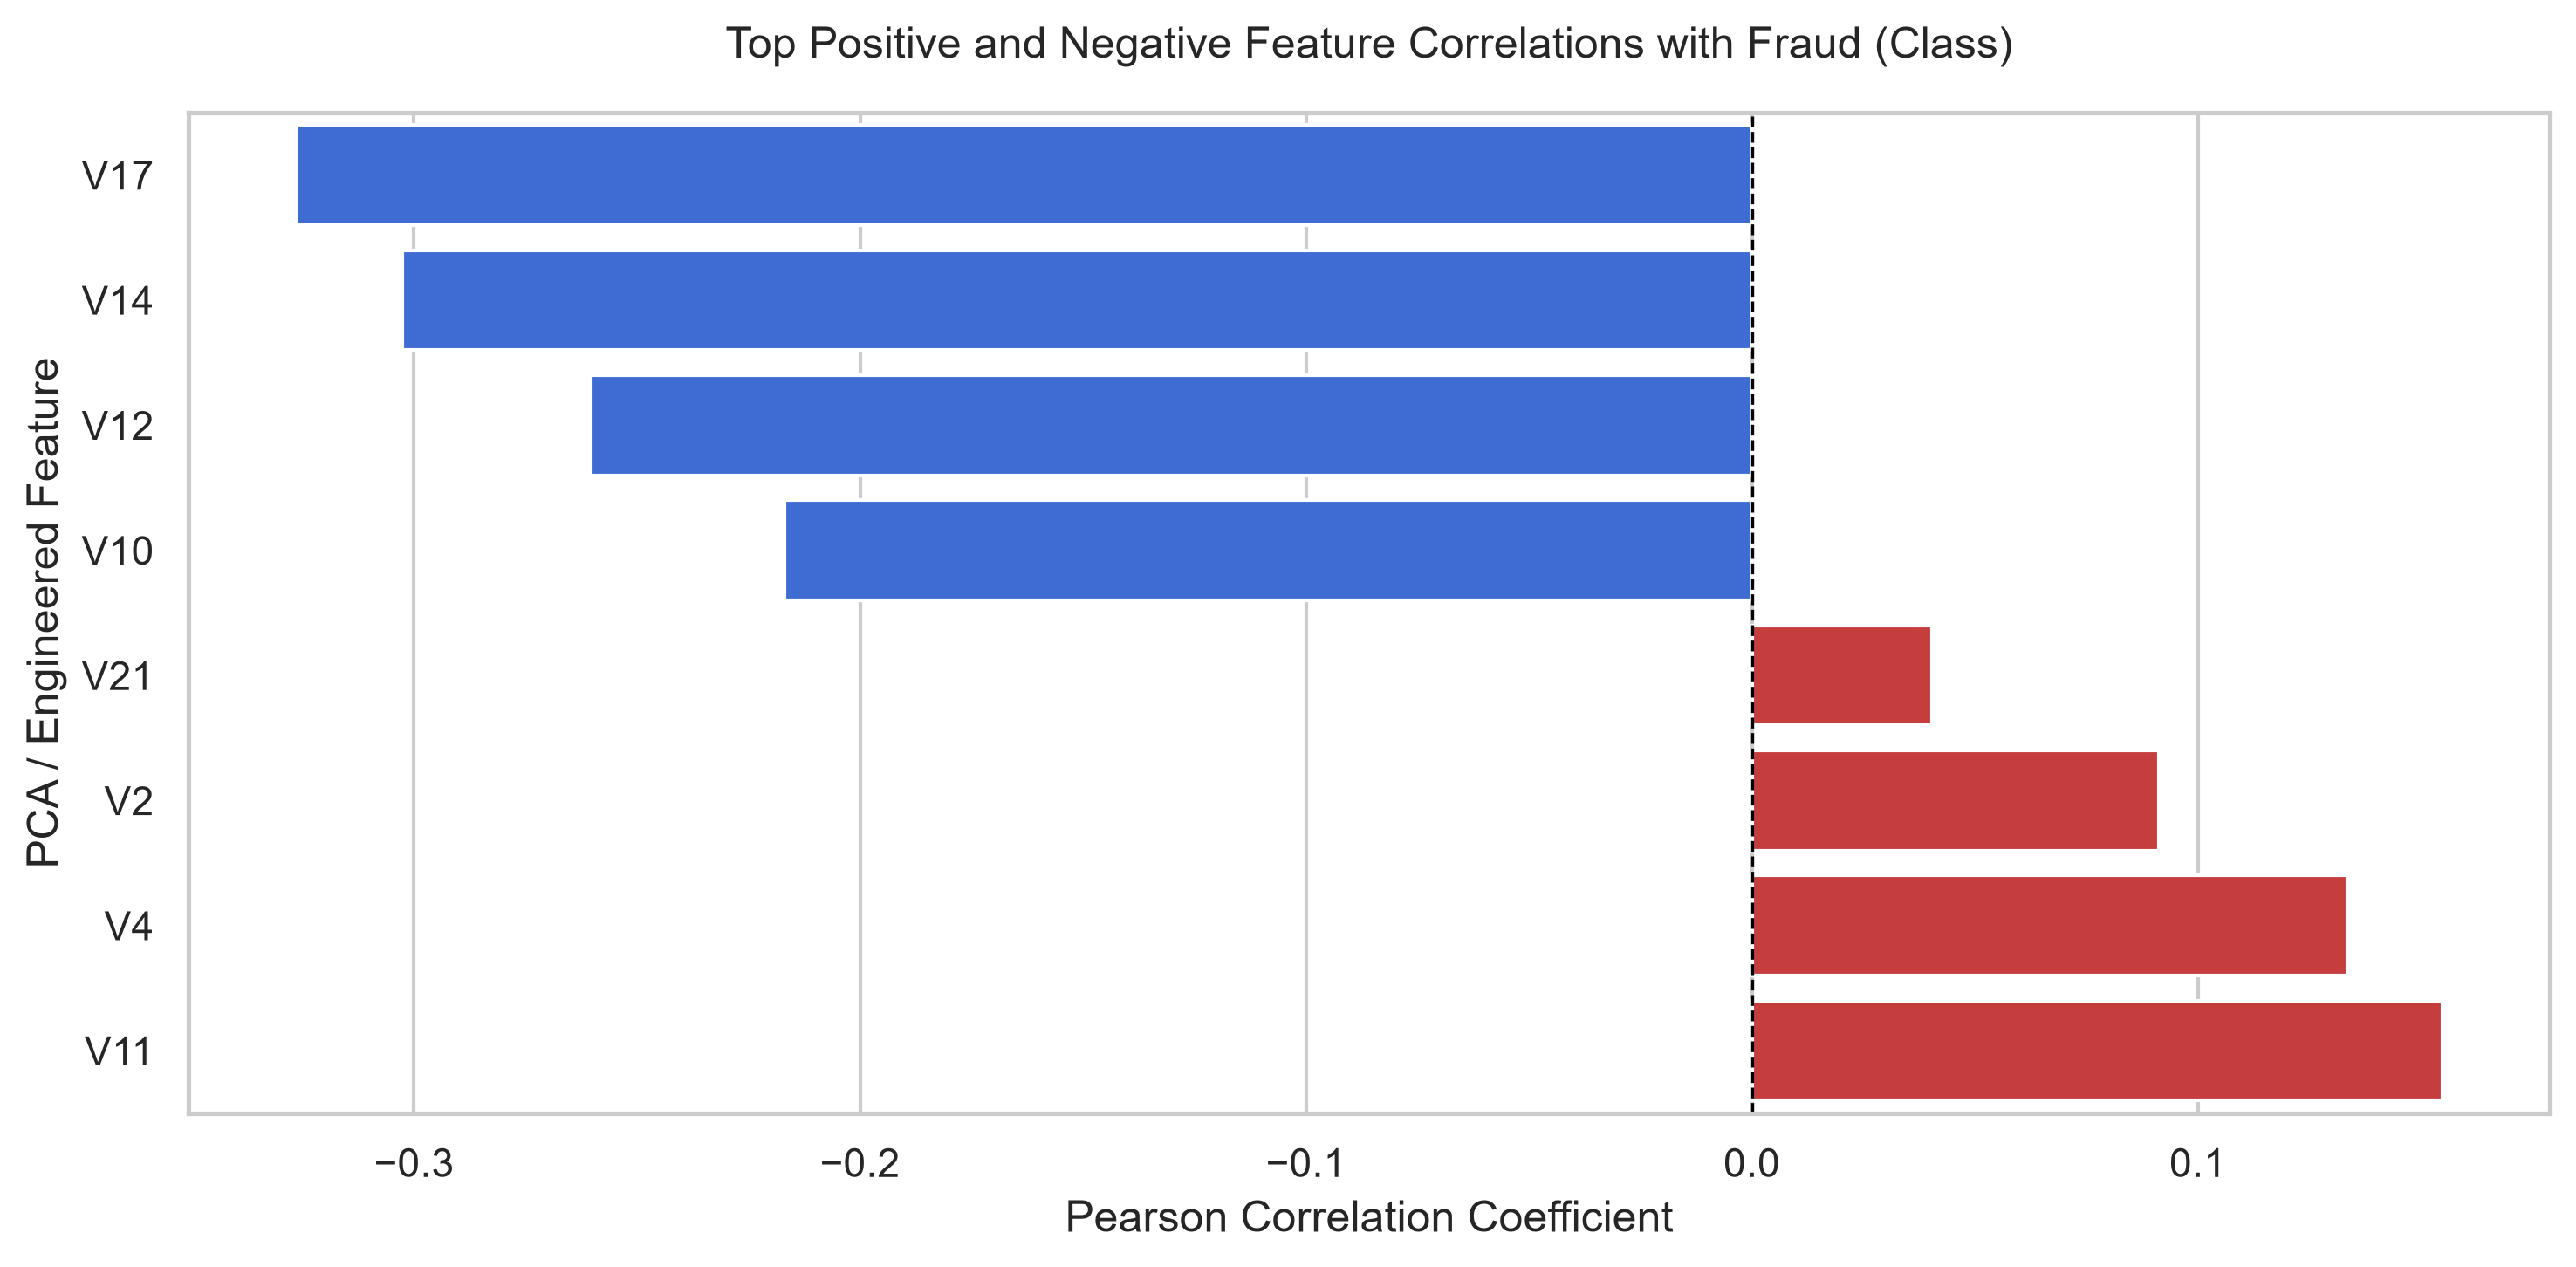

In [2]:
# 1a. Import Libraries & Styling Configuration.
#  First I will download the necessary libraries
import os
import sqlite3 
# Connects directly to the SQLite data warehouse (data/processed/fraud_warehouse.db) created by your ETL pipeline rather than reading the raw CSV. This proves your end-to-end integration across project components.
import pandas as pd
# Provides the core data structures (DataFrame, Series) for querying, aggregating, and filtering vector tabular data efficiently.
import numpy as np
# Performs element-wise mathematical calculations (log transformations, statistical aggregations) required for heavily skewed data.

# For Visualization, I will need to download the following libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Matplotlib provides the underlying canvas, axes control, and rendering engine, while Seaborn supplies high-level statistical plotting APIs (density estimations, heatmaps).

# Suppress warnings: This will help to keep the output clean and focused on the important information
import warnings
warnings.filterwarnings('ignore')
# Prevents pandas slice warnings or Matplotlib deprecation notices from cluttering rendered output cells in your final report.
# Aesthetic settings for the plots/ visualisations I will be creating
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 300
#Sets consistent typography, sizing, grid background, and high resolution (300 DPI), ensuring figures look crisp when exported for GitHub or your final submission deck.
print("Libraries imported and visualization styling applied successfully.")

#----------------------------------------------------------------------------
# 1b. Establish Database Connection and Load Data
#----------------------------------------------------------------------------

 # Establish connection to your ETL-processed SQLite Data Warehouse
db_path = "../data/processed/fraud_warehouse.db"
# Locates my transformed database using relative paths.
conn = sqlite3.connect(db_path)

# Execute SQL query to verify pipeline ingestion
query = "SELECT * FROM cleaned_transactions"
df = pd.read_sql_query(query, conn)

# Demonstrates SQL execution within a Python environment, highlighting integration across data engineering and data analytics domains.
# Close database connection immediately after reading into memory
conn.close()
# Establishes a standard database connection handle, executes the SQL read operation into Pandas memory, and explicitly closes the handle to prevent database locking issues.

# Verify structural dimensions and data types
print(f"Dataset Successfully Loaded from SQLite Warehouse.")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
df.info()

#----------------------------------------------------------------------------
# 2. Class Imbalance Analysis
#----------------------------------------------------------------------------

# RATIONALE: Calculate exact frequency counts and percentage distribution of target 'Class'.
# Essential for establishing the baseline challenge: severe minority class distribution (~0.17% fraud).
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

# RATIONALE: Package results into a structured summary table for clear report display.
imbalance_df = pd.DataFrame({
    'Total Transactions': class_counts,
    'Percentage (%)': class_percentages.round(4)
})
imbalance_df.index = ['Legitimate (0)', 'Fraudulent (1)']
print("--- Class Distribution Summary ---")
print(imbalance_df)

# RATIONALE: Plot distribution using Seaborn. Legitimate transactions (284,315) completely 
# dwarf fraudulent ones (492), making a linear bar plot misleading.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=imbalance_df.index, y='Total Transactions', data=imbalance_df, palette=['#2b5c8f', '#d9534f'], ax=ax)

# RATIONALE: Annotate exact raw numerical counts above each bar for precise communication.
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), 
               textcoords='offset points', fontweight='bold')

# RATIONALE: Apply logarithmic scaling to y-axis. Crucial analytical step—without log scale, 
# the fraud bar is too small to see visually alongside legitimate transactions.
ax.set_yscale('log')
ax.set_title('Target Variable Distribution (Logarithmic Scale)', pad=15)
ax.set_ylabel('Number of Transactions (Log Scale)')
ax.set_xlabel('Transaction Class')

plt.tight_layout()
plt.savefig('../docs/class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

#----------------------------------------------------------------------------
# 3. Statistical Profiling (Robust Scaling Evaluation)
#----------------------------------------------------------------------------

# RATIONALE: Group data by target Class and calculate descriptive statistics for scaled_amount.
# Transpose (.T) output into a side-by-side comparison table.
amount_stats = df.groupby('Class')['scaled_amount'].describe().T
amount_stats.columns = ['Legitimate (Class 0)', 'Fraudulent (Class 1)']

# RATIONALE: Explicitly compute Interquartile Range (IQR = 75th percentile - 25th percentile).
# Proves why RobustScaler (which uses median and IQR) was necessary in src/transform.py to 
# mitigate extreme financial outliers instead of standard mean/variance scalers.
amount_stats.loc['IQR'] = amount_stats.loc['75%'] - amount_stats.loc['25%']

print("--- Descriptive Statistics: Scaled Transaction Amount ---")
print(amount_stats.round(4))

#----------------------------------------------------------------------------
# 4. Temporal Analysis of Fraudulent Transactions
#----------------------------------------------------------------------------   
# RATIONALE: Aggregate transactions by engineered 'hour_of_day' (0-23) and 'Class' target.
# Unstack converts group indices into separate columns for volume and fraud count calculations.
hourly_summary = df.groupby(['hour_of_day', 'Class']).size().unstack(fill_value=0)

# RATIONALE: Compute hourly Fraud Rate percentage relative to total volume for each specific hour.
hourly_summary['Fraud_Rate_%'] = (hourly_summary[1] / (hourly_summary[0] + hourly_summary[1])) * 100

# RATIONALE: Construct a dual-axis visualization overlaying total volume (bar plot) with 
# fraud percentage (line plot) to evaluate temporal patterns on a unified timescale.
fig, ax1 = plt.subplots(figsize=(12, 5))

# RATIONALE: Render legitimate volume on primary left Y-axis. Uses subtle muted color 
# so it serves as background context without overwhelming the key takeaway.
sns.barplot(x=hourly_summary.index, y=hourly_summary[0], ax=ax1, color='#cbd5e1', alpha=0.6, label='Legitimate Volume')
ax1.set_ylabel('Legitimate Transaction Volume', color='#475569')
ax1.set_xlabel('Hour of Day (0 - 23)')

# RATIONALE: Create secondary right Y-axis for Fraud Rate percentage using twinx().
# Overlays a bold red line plot showing fraud proportion spikes during early morning hours (2-5 AM).
ax2 = ax1.twinx()
sns.lineplot(x=hourly_summary.index, y=hourly_summary['Fraud_Rate_%'], ax=ax2, color='#dc2626', marker='o', linewidth=2.5, label='Fraud Rate %')
ax2.set_ylabel('Fraud Rate (%)', color='#dc2626')
ax2.grid(False) # RATIONALE: Remove secondary grid lines to avoid visual confusion.

plt.title('Transaction Volume vs. Fraud Rate by Hour of Day', pad=15)
plt.tight_layout()
plt.savefig('../docs/hourly_fraud_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

#----------------------------------------------------------------------------
# 5. Correlation Analysis of Features
#----------------------------------------------------------------------------
# RATIONALE: Compute Pearson correlation matrix between all features and the target 'Class',
# dropping self-correlation (Class vs. Class = 1.0) and sorting by coefficient strength.
correlations = df.corr()['Class'].drop('Class').sort_values()

# RATIONALE: Filter and isolate top 4 strongest negative correlations and top 4 strongest positive 
# correlations. Excludes uninformative neutral noise features to focus on key predictive drivers.
top_neg_corr = correlations.head(4)
top_pos_corr = correlations.tail(4)
selected_correlations = pd.concat([top_neg_corr, top_pos_corr])

# RATIONALE: Render horizontal bar chart visualizing directional feature influence on fraud.
fig, ax = plt.subplots(figsize=(10, 5))

# RATIONALE: Dynamically color positive correlations red (increases fraud likelihood) 
# and negative correlations blue (decreases fraud likelihood) for visual clarity.
colors = ['#dc2626' if val > 0 else '#2563eb' for val in selected_correlations.values]
sns.barplot(x=selected_correlations.values, y=selected_correlations.index, palette=colors, ax=ax)

# RATIONALE: Add zero reference line to ground visual comparison of positive vs. negative correlation.
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Positive and Negative Feature Correlations with Fraud (Class)', pad=15)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_ylabel('PCA / Engineered Feature')

plt.tight_layout()
plt.savefig('../docs/feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()